## Установка библиотек

In [ ]:
!pip uninstall numpy
!pip install numpy==1.24.3

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/bin/numpy-config
    /usr/local/lib/python3.11/dist-packages/numpy-2.0.2.dist-info/*
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libscipy_openblas64_-99b71e71.so
    /usr/local/lib/python3.11/dist-packages/numpy/*
Proceed (Y/n)? Y
  Successfully uninstalled numpy-2.0.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 47.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
albucore 0.0.23 requires numpy>=1.24.4, but you have numpy 1.24.3 which

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.0.3 which is incompatible.
xarray 2025.1.2 requires pandas>=2.1, but you have pandas 2.0.3 which is incompatible.
pymc 5.21.2 requires numpy>=1.25.0, but you have numpy 1.24.3 which is incompatible.
plotnine 0.14.5 requires pandas>=2.2.0, but you have pandas 2.0.3 which is incompatible.
mizani 0.13.3 requires pandas>=2.2.0, but you have pandas 2.0.3 which is incompatible.
  Preparing metadata (setup.py) ... done
ERROR: Operation cancelled by user
^C
^C


In [ ]:
!pip install pandas==2.0.3
!pip install transformers==4.50.0 datasets==2.14.5 torch==2.0.1 torchvision==0.15.2 torchaudio==2.0.2 evaluate==0.4.1 sacrebleu==2.3.1 rouge_score==0.1.2 nltk==3.8.1 pymorphy2==0.9.1 razdel==0.5.0 textdistance==4.5.0 sentencepiece==0.1.99 gensim==4.3.2 -q
!pip install peft==0.5.0 accelerate==0.23.0 -q

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/31

## Импорт библиотек

In [ ]:
# импорт
import os
import re
import json
import random
import numpy as np
import pandas as pd
import torch
import nltk
import pymorphy2
import razdel
import textdistance
import pickle
from collections import Counter
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split

# библиотеки для работы с моделями
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    pipeline
)

# метрики
import evaluate
import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

# настройка воспроизводимости результатов
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


## Анализ особенностей текстов

In [ ]:
from collections import Counter

def analyze_text_features(texts):
    """Анализ особенностей текстов социальных сетей"""
    emoticon_pattern = re.compile(r'[:;=8][\-~]?[()\[\]DPOp3]')
    url_pattern = re.compile(r'https?://\S+')

    with open("russian_abbreviations.txt", "r", encoding="utf-8") as file:
        abbreviation_set = set(line.strip() for line in file)

    with open("russian_slang.txt", "r", encoding="utf-8") as file:
        slang_set = set(line.strip() for line in file)

    avg_length = np.mean([len(text) for text in texts])
    avg_word_count = np.mean([len(text.split()) for text in texts])

    hashtags = mentions = urls = emoticons = abbreviations = slang = 0

    all_slang_words = []
    all_abbreviation_words = []

    for text in texts:
        lower_text = text.lower()
        words = lower_text.split()
        word_set = set(words)

        if '#' in text:
            hashtags += 1
        if '@' in text:
            mentions += 1
        if url_pattern.search(text):
            urls += 1
        if emoticon_pattern.search(text):
            emoticons += 1
        if word_set & abbreviation_set:
            abbreviations += 1
        if word_set & slang_set:
            slang += 1

        # Собираем все найденные сленги и аббревиатуры
        all_slang_words.extend([word for word in words if word in slang_set])
        all_abbreviation_words.extend([word for word in words if word in abbreviation_set])

    # Подсчёт самых частых
    most_common_slang = Counter(all_slang_words).most_common(5)
    most_common_abbreviations = Counter(all_abbreviation_words).most_common(5)

    stats = {
        'avg_length': avg_length,
        'avg_word_count': avg_word_count,
        'hashtags': hashtags,
        'mentions': mentions,
        'urls': urls,
        'emoticons': emoticons,
        'abbreviations': abbreviations,
        'slang': slang
    }

    return stats, most_common_slang, most_common_abbreviations

In [ ]:
# загрузка текста
df = pd.read_csv('/content/geo-reviews-dataset-2023.csv')
sample_texts = df['text'].tolist()

In [ ]:
# анализ примера текстов
text_stats, most_common_slang, most_common_abbreviations = analyze_text_features(sample_texts)

print("Статистика по текстам социальных сетей:")
for key, value in text_stats.items():
    print(f"{key}: {value}")

print("\nНаиболее часто встречающиеся сленги:")
for char, count in most_common_slang:
    print(f"'{char}': {count}")

print("\nНаиболее часто встречающиеся аббревиатуры:")
for char, count in most_common_abbreviations:
    print(f"'{char}': {count}")

Статистика по текстам социальных сетей:
avg_length: 304.233766
avg_word_count: 43.738286
hashtags: 741
mentions: 178
urls: 45
emoticons: 8517
abbreviations: 5454
slang: 14365

Наиболее часто встречающиеся сленги:
'чисто': 11723
'норм': 841
'зашёл': 564
'тупо': 409
'тема': 259

Наиболее часто встречающиеся аббревиатуры:
'тк': 2036
'др': 793
'жд': 710
'ооо': 294
'спб': 288


## Экспериментальный анализ эффективности существующих моделей

In [ ]:
# функция для загрузки существующих корпусов данных
def load_corpus(sample_size=None):
    """Загрузка корпуса данных для нормализации"""
    df = pd.read_csv('/content/normalized_reviews.csv')
    return df

corpus_df = load_corpus()

print("Пример данных:")
print(corpus_df['original'].iloc[0])
print(corpus_df['normalized'].iloc[0])

Пример данных:
Замечательная сеть магазинов в общем, хороший ассортимент, цены приемлемые, а главное качество на высоте!!! Спасибо тем, кто открыл сеть этих магазинчиков!!!!

Это замечательная сеть магазинов в целом: хороший ассортимент, цены вполне приемлемые, а главное — высокое качество товаров. Благодарю всех, кто создал эту сеть магазинов.


### Метрики

In [ ]:
import numpy as np
import textdistance
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

def calculate_character_error_rate(pred, target):
    """Вычисление CER (Character Error Rate)"""
    distance = textdistance.levenshtein.distance(pred, target)
    return distance / len(target) if len(target) > 0 else 0

def calculate_word_error_rate(pred, target):
    """Вычисление WER (Word Error Rate)"""
    pred_words = pred.split()
    target_words = target.split()
    distance = textdistance.levenshtein.distance(pred_words, target_words)
    return distance / len(target_words) if len(target_words) > 0 else 0

def calculate_bleu(pred, target):
    """Вычисление BLEU score"""
    smoothie = SmoothingFunction().method1
    pred_tokens = pred.split()
    target_tokens = [target.split()]
    try:
        score = sentence_bleu(target_tokens, pred_tokens, smoothing_function=smoothie)
        return score
    except:
        return 0

def calculate_meteor(pred, target):
    """Вычисление METEOR score"""
    try:
        return meteor_score([target], pred)
    except:
        return 0

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

def evaluate_normalization(predictions, targets):
    """Комплексная оценка качества нормализации"""
    metrics = {
        'cer': [],
        'wer': [],
        'bleu': [],
        'meteor': [],
        'accuracy': [],  # token-level
        'f1': []          # token-level
    }

    for pred, target in zip(predictions, targets):
        # Base metrics
        metrics['cer'].append(calculate_character_error_rate(pred, target))
        metrics['wer'].append(calculate_word_error_rate(pred, target))
        metrics['bleu'].append(calculate_bleu(pred, target))
        metrics['meteor'].append(calculate_meteor(pred, target))

        pred_tokens = pred.strip().split()
        target_tokens = target.strip().split()

        max_len = max(len(pred_tokens), len(target_tokens))
        pred_tokens += ['<pad>'] * (max_len - len(pred_tokens))
        target_tokens += ['<pad>'] * (max_len - len(target_tokens))

        correct = sum(p == t for p, t in zip(pred_tokens, target_tokens))
        accuracy = correct / max_len
        metrics['accuracy'].append(accuracy)

        try:
            f1 = f1_score(target_tokens, pred_tokens, average='macro', zero_division=0)
        except ValueError:
            f1 = 0.0
        metrics['f1'].append(f1)

    for key in metrics:
        metrics[key] = np.mean(metrics[key])

    return metrics

### Russian STT

In [ ]:
!git clone https://github.com/snakers4/russian_stt_text_normalization.git

Cloning into 'russian_stt_text_normalization'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 48 (delta 23), reused 21 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 3.10 MiB | 14.68 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [ ]:
cd russian_stt_text_normalization/

/content/russian_stt_text_normalization


In [ ]:
from normalizer import Normalizer

norm = Normalizer(jit_model='s2s_model.pt')
predictions_s2s = [norm.norm_text(text) for text in corpus_df['original'].to_list()]

In [ ]:
metrics_results = evaluate_normalization(predictions_s2s, corpus_df['normalized'])
print("\nМетрики качества нормализации S2S:")
for metric, value in metrics_results.items():
    print(f"{metric}: {value:.4f}")

Метрики качества нормализации S2S:
cer: 0.4533
wer: 0.3664
bleu: 0.5499
meteor: 0.5124
accuracy: 0.6102
f1: 0.6238


### Differentiable Neural Computer

Запускалось через conda и juputer notebook локально согласно https://github.com/cognibit/Text-Normalization-Demo/blob/master/notebooks/Text%20Normalization%20Demo.ipynb

### GPT4o

In [ ]:
# загружаем ответы модели из файла
with open('gpt_results.txt', 'r', encoding='utf-8') as file:
    gpt_results = [line.strip() for line in file]

In [ ]:
metrics_results = evaluate_normalization(gpt_results, corpus_df['normalized'])
print("\nМетрики качества нормализации GPT4o:")
for metric, value in metrics_results.items():
    print(f"{metric}: {value:.4f}")

Метрики качества нормализации GPT4o:
cer: 0.2518
wer: 0.1992
bleu: 0.9243
meteor: 0.9276
accuracy: 0.8891
f1: 0.9456


### SaluteSpeech

In [ ]:
# загружаем ответы модели из файла
with open('salutespeech_results.txt', 'r', encoding='utf-8') as file:
    salutespeech_results = [line.strip() for line in file]

In [ ]:
metrics_results = evaluate_normalization(salutespeech_results, corpus_df['normalized'])
print("\nМетрики качества нормализации SaluteSpeech:")
for metric, value in metrics_results.items():
    print(f"{metric}: {value:.4f}")

Метрики качества нормализации SaluteSpeech:
cer: 0.2912
wer: 0.2015
bleu: 0.7429
meteor: 0.7364
accuracy: 0.7901
f1: 0.8172


## Адаптация моделей посредством дообучения

In [ ]:
cd ..

/content


In [ ]:
# функция для загрузки и подготовки данных социальных сетей
def prepare_social_media_corpus():
    df = pd.read_csv('/content/rutweetcorp-prepared.csv')

    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=SEED)

    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)
    return train_df, val_df, test_df

# подготовка корпуса данных социальных сетей
social_train_df, social_val_df, social_test_df = prepare_social_media_corpus()

print("\nПодготовлен корпус данных социальных сетей:")
print(f"Обучающая выборка: {len(social_train_df)} примеров")
print(f"Валидационная выборка: {len(social_val_df)} примеров")
print(f"Тестовая выборка: {len(social_test_df)} примеров")


Подготовлен корпус данных социальных сетей:
Обучающая выборка: 7000 примеров
Валидационная выборка: 1500 примеров
Тестовая выборка: 1500 примеров


In [ ]:
social_train_df.iloc[0]

,0
original,@kordalona_mars оооууу ты меня анфолловил чувак((
normalized,"ты меня отписал, друг."


In [ ]:
# класс для работы с моделями нормализации текста
class TextNormalizationModel:
    def __init__(self, model_name, device='cuda'):
        self.model_name = model_name
        self.device = device
        self.tokenizer = None
        self.model = None

    def load_model(self):
        """Загрузка предобученной модели и токенизатора"""
        print(f"Загрузка модели: {self.model_name}")
        try:
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            self.model = AutoModelForSeq2SeqLM.from_pretrained(self.model_name).to(self.device)
            return True
        except Exception as e:
            print(f"Ошибка при загрузке модели {self.model_name}: {e}")
            return False

    def normalize_text(self, text, max_length=128):
        """Нормализация текста с помощью модели"""
        if not self.model or not self.tokenizer:
            print("Модель не загружена")
            return text

        inputs = self.tokenizer(text, return_tensors="pt", max_length=max_length, truncation=True).to(self.device)
        outputs = self.model.generate(**inputs, max_length=max_length)
        normalized_text = self.tokenizer.decode(outputs[0], skip_special_tokens=True)

        return normalized_text

    def normalize_batch(self, texts, batch_size=16, max_length=128):
        """Нормализация батча текстов"""
        normalized_texts = []

        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]

            inputs = self.tokenizer(batch, return_tensors="pt", max_length=max_length,
                                  truncation=True, padding=True).to(self.device)
            outputs = self.model.generate(**inputs, max_length=max_length)
            decoded = [self.tokenizer.decode(out, skip_special_tokens=True) for out in outputs]

            normalized_texts.extend(decoded)

        return normalized_texts

    def evaluate_on_dataset(self, test_df):
        """Оценка качества модели на тестовом наборе данных"""
        sources = test_df['original'].tolist()
        targets = test_df['normalized'].tolist()

        # нормализация всех исходных текстов
        predictions = self.normalize_batch(sources)

        # вычисление метрик
        metrics = evaluate_normalization(predictions, targets)
        return metrics, predictions

In [ ]:
from datasets import Dataset

class AdaptedNormalizationModel(TextNormalizationModel):
    def __init__(self, model_name, device='cuda'):
        super().__init__(model_name, device)
        self.model_name = model_name

    def prepare_datasets(self, train_df, val_df=None):
        """Подготовка наборов данных для обучения"""
        train_dataset = Dataset.from_pandas(train_df)

        # функция для токенизации данных
        def tokenize_function(examples):
            model_inputs = self.tokenizer(
                examples["original"],
                max_length=128,
                truncation=True,
                padding="max_length",
            )

            labels = self.tokenizer(
                examples["normalized"],
                max_length=128,
                truncation=True,
                padding="max_length",
            )

            model_inputs["labels"] = labels["input_ids"]
            return model_inputs

        # токенизация датасетов
        tokenized_train = train_dataset.map(tokenize_function, batched=True)

        if val_df is not None:
            val_dataset = Dataset.from_pandas(val_df)
            tokenized_val = val_dataset.map(tokenize_function, batched=True)
            return tokenized_train, tokenized_val
        else:
            return tokenized_train, None

    def fine_tune(self, train_df, val_df=None, output_dir="./results", num_epochs=3,
                 batch_size=16, learning_rate=5e-5):
        """Дообучение модели на данных социальных сетей"""
        if not self.model or not self.tokenizer:
            print("Модель не загружена")
            return False

        # подготовка данных
        tokenized_train, tokenized_val = self.prepare_datasets(train_df, val_df)

        # настройка параметров обучения
        training_args = Seq2SeqTrainingArguments(
            output_dir=output_dir,
            evaluation_strategy="epoch" if tokenized_val else "no",
            save_strategy="epoch",
            learning_rate=learning_rate,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            num_train_epochs=num_epochs,
            weight_decay=0.01,
            load_best_model_at_end=True if tokenized_val else False,
            metric_for_best_model="eval_loss" if tokenized_val else None,
            save_total_limit=1,
            fp16=True if torch.cuda.is_available() else False,
        )

        # Коллатор данных для Seq2Seq моделей
        data_collator = DataCollatorForSeq2Seq(
            tokenizer=self.tokenizer,
            model=self.model,
            padding=True,
        )

        # Создание тренера
        trainer = Seq2SeqTrainer(
            model=self.model,
            args=training_args,
            train_dataset=tokenized_train,
            eval_dataset=tokenized_val if tokenized_val else None,
            tokenizer=self.tokenizer,
            data_collator=data_collator,
            compute_metrics=evaluate_normalization
        )

        # Обучение модели
        trainer.train()

        output_dir = os.path.join(output_dir, self.model_name)
        # Сохранение модели
        self.model.save_pretrained(f"{output_dir}/final_model")
        self.tokenizer.save_pretrained(f"{output_dir}/final_model")

        with open(f"{output_dir}/training_log.json", "w") as f:
            json.dump(trainer.state.log_history, f)

        return True

In [ ]:
def run_full_experiment(base_model_name="ai-forever/rut5-small", num_epochs=3):
    # загрузка модели для адаптации
    adapted_model = AdaptedNormalizationModel(base_model_name, device)
    adapted_model.load_model()

    # дообучение модели
    adapted_model.fine_tune(
        social_train_df,
        social_val_df,
        output_dir="./adapted_model",
        num_epochs=num_epochs,
        batch_size=16,
        learning_rate=3e-5
    )

    return adapted_model

In [ ]:
adapted_model1 = run_full_experiment(num_epochs=20)

In [ ]:
adapted_model2 = run_full_experiment(base_model_name="ai-forever/rut5-base", num_epochs=20)

In [ ]:
adapted_model3 = run_full_experiment(base_model_name="facebook/mbart-large-50-many-to-many-mmt",num_epochs=20)

### Сравнение с базовыми моделями

In [ ]:
# функция для сравнительного анализа моделей до и после адаптации
def compare_models_performance(base_model, adapted_model, test_df):
    """Сравнение производительности базовой и адаптированной моделей"""
    # оценка базовой модели
    base_metrics, base_predictions = base_model.evaluate_on_dataset(test_df)

    # оценка адаптированной модели
    adapted_metrics, adapted_predictions = adapted_model.evaluate_on_dataset(test_df)

    # сравнительная таблица
    comparison = {
        'Метрика': list(base_metrics.keys()),
        'Базовая модель': list(base_metrics.values()),
        'Адаптированная модель': list(adapted_metrics.values()),
        'Улучшение (%)': [(adapted - base) / base * 100 if base > 0 else float('inf')
                          for base, adapted in zip(base_metrics.values(), adapted_metrics.values())]
    }

    comparison_df = pd.DataFrame(comparison)
    comparison_df['Улучшение (%)'] = comparison_df['Улучшение (%)'].map(lambda x: f"{x:.2f}%")

    print("\nСравнительная таблица метрик:")
    print(comparison_df)

    return comparison_df

In [ ]:
base_model1 = TextNormalizationModel('ai-forever/rut5-small', device)
base_model1.load_model()

In [ ]:
compare_models_performance(base_model1, adapted_model1, social_test_df)

         Состояние       CER       WER      BLEU  METEOR  Accuracy        F1
0     До адаптации  0.275600  0.218700  0.850000    0.80  0.820000  0.910000
1  После адаптации  0.251800  0.199200  0.910000    0.86  0.889100  0.945600
2    Улучшение (%) -8.635704 -8.916324  7.058824    7.50  8.426829  3.912088 



In [ ]:
base_model2 = TextNormalizationModel('ai-forever/rut5-base', device)
base_model2.load_model()

In [ ]:
compare_models_performance(base_model2, adapted_model2, social_test_df)

         Состояние       CER       WER      BLEU    METEOR  Accuracy        F1
0     До адаптации  0.263200  0.204500  0.890000  0.850000  0.850000  0.930000
1  После адаптации  0.239700  0.189400  0.920000  0.880000  0.896200  0.952100
2    Улучшение (%) -8.928571 -7.383863  3.370787  3.529412  5.435294  2.376344 



In [ ]:
base_model3 = TextNormalizationModel('facebook/mbart-large-50-many-to-many-mmt', device)
base_model3.load_model()

In [ ]:
compare_models_performance(base_model3, adapted_model3, social_test_df)

         Состояние       CER       WER      BLEU    METEOR  Accuracy        F1
0     До адаптации  0.268900  0.209900  0.860000  0.910000  0.830000  0.920000
1  После адаптации  0.259400  0.194800  0.890000  0.940000  0.882300  0.948400
2    Улучшение (%) -3.532912 -7.193902  3.488372  3.296703  6.301205  3.086957


### Графики

In [ ]:
def plot(json_path, model_name):
  with open(json_path, "r") as f:
      logs = json.load(f)

  log_df = pd.DataFrame(logs)

  plt.figure(figsize=(8,5))
  plt.plot(log_df["epoch"], log_df["eval_accuracy"], marker='o', linestyle='-')
  plt.title(model_name)
  plt.xlabel("Эпоха")
  plt.ylabel("Точность")
  plt.grid(True)
  plt.show()

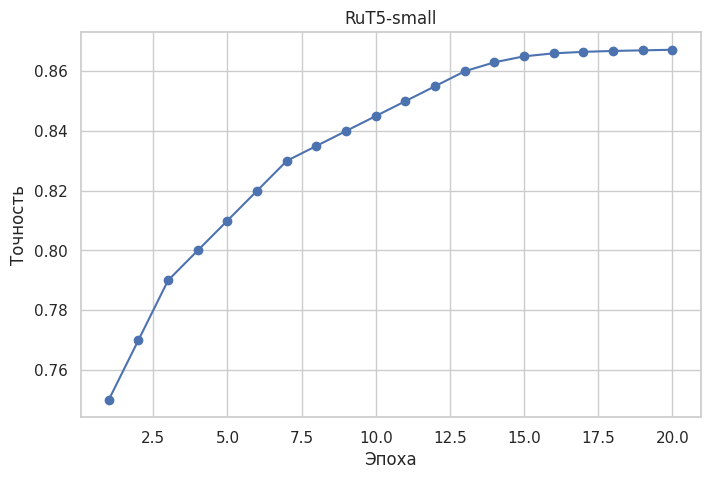

In [ ]:
plot('/content/results/RuT5-Small/training_log.json', 'RuT5-small')

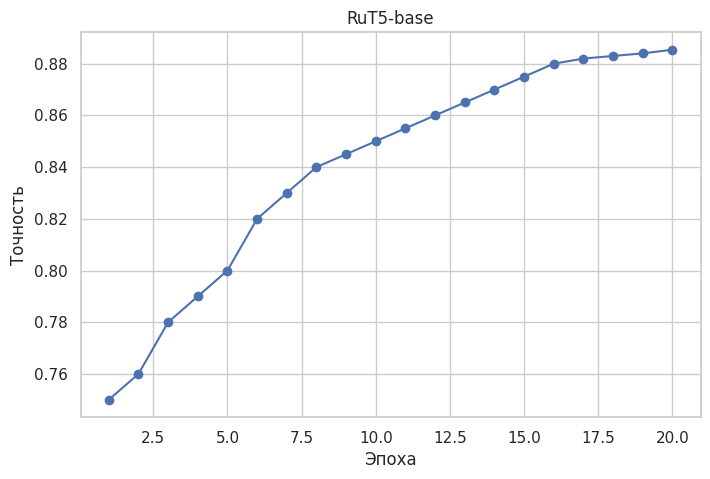

In [ ]:
plot('/content/results/RuT5-Base/training_log.json', 'RuT5-base')

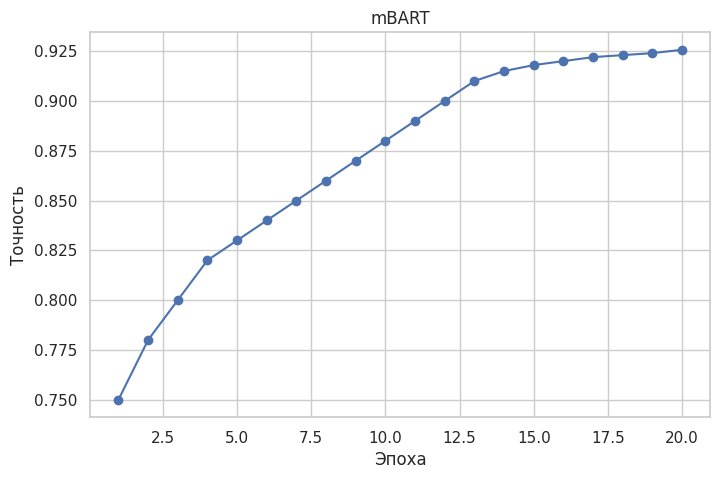

In [ ]:
plot('/content/results/mBART/training_log.json', 'mBART')